# ADSP 32018 IP01 Next-Gen NLP: Transformers, LLMs and AgenticAI in Practice - Final Project

## Part 5: Sentiment Model Train


**Objective of this Notebook:**

The purpose of this notebook is to build a document-level sentiment classifier for organization-specific AI discussion. I first construct a labeled training dataset by extracting organization-centered text contexts from the entity extraction outputs and then use an LLM-based weak labeling step to assign one of four sentiment classes: **positive**, **neutral**, **negative**, or **unclear**. Using these labeled examples, I fine-tune a transformer-based classifier based on **`roberta-base`** so that sentiment can later be predicted at scale across organizations, industries, and AI-related narratives in the corpus.

**Plan:**

- Load the entity extraction outputs and build organization-centered context windows that preserve the local sentence-level meaning around each entity mention.
- Inspect the resulting context dataset to verify that the extracted snippets are readable, informative, and suitable for sentiment annotation.
- Use an OpenAI model for weak labeling to assign sentiment labels to a large sample of organization-context examples, while caching results to make the process reproducible and efficient.
- Save the labeled dataset and prepare it for supervised model training.
- Fine-tune **`roberta-base`** as a four-class sequence classifier using the weakly labeled data.
- Use stratified train-validation splitting, tokenizer-based preprocessing, and class-weighted loss to address label imbalance.
- Evaluate model performance on the validation set using accuracy, macro F1, a classification report, and a confusion matrix.
- Save the trained model artifacts so that the classifier can be applied in the downstream sentiment inference stage.


## 0. Imports and Environment Setup

This section imports the Python libraries used throughout the notebook, including data handling tools, model training utilities, evaluation metrics, and transformer components. It also reads the OpenAI API key from the environment so that the weak-labeling step can call the external model later in the workflow.


In [ ]:
import os
import json
import re
import time
import random
import hashlib
from pathlib import Path
from threading import Lock
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import spacy
import evaluate
import torch
from datasets import Dataset

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed,
)

import openai
from openai import OpenAI

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

## 1. Build Organization-Centered Sentiment Contexts

### 1.1 Load the Entity Extraction Output

This step loads the structured entity dataset produced in the earlier entity extraction notebook. The goal here is to start from document-level records that already contain organization mentions and their spans, which can then be converted into local text snippets for sentiment labeling.

In [2]:
df = pd.read_parquet("./data/entity/entity_extract.parquet", engine="pyarrow")
df.head()

,row_id,date,language,title,title_clean,text,text_clean_light,url,char_count,token_count,...,model_text,topic_id,topic_confidence,is_top_10,is_top_20,industry,org_entity,org_entity_spans,tech_entity,tech_entity_span
0,2199,2022-01-01,en,"Telecom giant KT to develop its own NPU, AI ec...","Telecom giant KT to develop its own NPU, AI ec...","Telecom giant KT to develop its own NPU, AI ec...","Telecom giant KT to develop its own NPU, AI ec...",https://www.newsbreak.com/news/2472208289685/t...,13117,1674,...,Telecom giant KT to develop its own NPU AI eco...,2,1.000000,True,True,Sales and Related,[. PoliticsMilitaryCongress & CourtsElectionsL...,"[[337, 396], [1948, 1962], [1969, 1971], [2142...",[],[]
1,69671,2022-01-01,en,Garrison named one of ‘Washington’s Most Power...,Garrison named one of ‘Washington’s Most Power...,Garrison named one of ‘Washington’s Most Power...,Garrison named one of ‘Washington’s Most Power...,https://vestaviavoice.com/peopleplaces/garriso...,2222,348,...,Garrison named one of Washington s Most Powerf...,-1,0.000000,False,False,Other/Unclustered,"[Clearview AI - VestaviaVoice, People Garrison...","[[125, 153], [163, 178], [295, 316], [433, 445...",[],[]
2,94772,2022-01-01,en,Instapundit » Blog Archive » HMM: An Advan...,Instapundit » Blog Archive » HMM: An Advanced ...,Instapundit » Blog Archive » HMM: An Advan...,Instapundit » Blog Archive » HMM: An Advanced ...,https://pjmedia.com/instapundit/494418/,117,20,...,Instapundit Blog Archive HMM An Advanced AI Ga...,-1,0.000000,False,False,Other/Unclustered,[],[],[],[]
3,96660,2022-01-01,en,5 Places to Start a Career in Data Science in ...,5 Places to Start a Career in Data Science in ...,5 Places to Start a Career in Data Science in ...,5 Places to Start a Career in Data Science in ...,https://www.newsbreak.com/news/2470570042311/5...,15628,2220,...,5 Places to Start a Career in Data Science in ...,2,0.971146,True,True,Sales and Related,[. PoliticsMilitaryCongress & CourtsElectionsL...,"[[334, 393], [2705, 2711], [2756, 2762], [3024...",[],[]
4,117462,2022-01-01,en,Datametrex AI (CVE:DM) Trading Down 8% - Enter...,Datametrex AI (CVE:DM) Trading Down 8% - Enter...,Shares of Datametrex AI Limited (CVE:DM) fell ...,Shares of Datametrex AI Limited (CVE:DM) fell ...,https://theenterpriseleader.com/2022/01/01/dat...,1147,171,...,Shares of Datametrex AI Limited CVE DM fell 8 ...,-1,0.000000,False,False,Other/Unclustered,"[Datametrex AI Limited, Datametrex AI Limited,...","[[10, 31], [285, 306], [767, 781], [786, 799],...",[],[]


### 1.2 Construct Sentence-Based Context Windows Around Organization Mentions

This section defines the helper functions used to transform raw document text into training-ready sentiment examples. The pipeline standardizes span formats, splits documents into sentence boundaries, and then builds a centered context window around each organization mention, marking the entity explicitly so that the sentiment model can focus on the correct target. The final output of this step is a long-format dataset where each row corresponds to one organization mention and its associated local context.


In [ ]:
nlp_sent = spacy.blank("en")
nlp_sent.add_pipe("sentencizer")


def force_pylist(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    try:
        import pyarrow as pa
        if isinstance(x, pa.Scalar):
            x = x.as_py()
    except Exception:
        pass
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, (list, tuple)):
        return list(x)
    return [x]

def ensure_tuple_span(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    if isinstance(x, np.ndarray):
        x = x.tolist()
    if isinstance(x, tuple) and len(x) == 2:
        return (int(x[0]), int(x[1]))
    if isinstance(x, list) and len(x) == 2:
        return (int(x[0]), int(x[1]))
    if isinstance(x, str):
        m = re.findall(r"-?\d+", x)
        if len(m) >= 2:
            return (int(m[0]), int(m[1]))
    return None

def normalize_spans_list(spans_cell):
    spans = force_pylist(spans_cell)
    out = []
    for item in spans:
        t = ensure_tuple_span(item)
        if t is not None:
            out.append(t)
    return out

def get_sent_bounds(text: str):
    if text is None:
        return []
    s = str(text)
    if not s.strip():
        return []
    doc = nlp_sent(s)
    return [(sent.start_char, sent.end_char) for sent in doc.sents]


def build_entity_context_with_bounds(
    s: str,
    span,
    sent_bounds,
    tag_open: str = "<ENT>",
    tag_close: str = "</ENT>",
    max_chars: int | None = 1200,
):
    if s is None or not str(s).strip():
        return {"context": None, "status": "empty_text"}

    s = str(s)
    span = ensure_tuple_span(span)
    if span is None:
        return {"context": None, "status": "bad_span"}

    start, end = span
    if start < 0 or end < 0 or start >= len(s) or end > len(s) or start >= end:
        return {"context": None, "status": "span_out_of_range"}

    if not sent_bounds:
        left = max(0, start - 200)
        right = min(len(s), end + 200)
        frag = s[left:right]
        rs, re_ = start - left, end - left
        tagged = frag[:rs] + tag_open + frag[rs:re_] + tag_close + frag[re_:]
        return {"context": tagged, "status": "no_sents_fallback_window"}

    sent_idx = None
    for i, (a, b) in enumerate(sent_bounds):
        if start >= a and start < b:
            sent_idx = i
            break

    if sent_idx is None:
        left = max(0, start - 200)
        right = min(len(s), end + 200)
        frag = s[left:right]
        rs, re_ = start - left, end - left
        tagged = frag[:rs] + tag_open + frag[rs:re_] + tag_close + frag[re_:]
        return {"context": tagged, "status": "span_not_in_sentence_fallback_window"}

    prev_idx = max(0, sent_idx - 1)
    next_idx = min(len(sent_bounds) - 1, sent_idx + 1)

    ctx_start = sent_bounds[prev_idx][0]
    ctx_end = sent_bounds[next_idx][1]

    frag = s[ctx_start:ctx_end]
    rs, re_ = start - ctx_start, end - ctx_start
    tagged = frag[:rs] + tag_open + frag[rs:re_] + tag_close + frag[re_:]

    if max_chars is not None and len(tagged) > max_chars:
        center = (rs + re_) // 2
        half = max_chars // 2
        L = max(0, center - half)
        R = min(len(tagged), center + half)
        tagged = tagged[L:R]

    return {"context": tagged, "status": "ok"}

def explode_entities_fast(
    df: pd.DataFrame,
    entity_col: str = "org_entity",
    span_col: str = "org_entity_spans",
    text_col: str = "text_clean_light",
    keep_cols: list[str] | None = None,
):
    if keep_cols is None:
        keep_cols = ["row_id", "date", "language", "url", "industry"]

    base = df[keep_cols + [text_col, entity_col, span_col]].copy()

    base[entity_col] = base[entity_col].apply(force_pylist)
    base[span_col] = base[span_col].apply(normalize_spans_list)

    ents = base[entity_col].tolist()
    spans = base[span_col].tolist()
    base["pairs"] = [list(zip(e, sp))[: min(len(e), len(sp))] for e, sp in zip(ents, spans)]

    base = base.drop(columns=[entity_col, span_col])

    long_df = base.explode("pairs", ignore_index=True)
    long_df = long_df.dropna(subset=["pairs"]).copy()

    pair_df = pd.DataFrame(long_df["pairs"].tolist(), index=long_df.index, columns=[entity_col, span_col])
    long_df = pd.concat([long_df.drop(columns=["pairs"]), pair_df], axis=1)

    long_df[entity_col] = long_df[entity_col].astype(str).str.strip()
    long_df = long_df[long_df[entity_col].ne("")].copy()

    long_df[span_col] = long_df[span_col].apply(ensure_tuple_span)
    long_df = long_df.dropna(subset=[span_col]).copy()

    return long_df


def build_org_entity_context_dataset(
    df: pd.DataFrame,
    entity_col: str = "org_entity",
    span_col: str = "org_entity_spans",
    text_col: str = "text_clean_light",
    keep_cols: list[str] | None = None,
    max_chars: int | None = 1200,
    dedup: bool = True,
):
    if keep_cols is None:
        keep_cols = ["row_id", "date", "language", "url", "industry"]

    long_df = explode_entities_fast(
        df,
        entity_col=entity_col,
        span_col=span_col,
        text_col=text_col,
        keep_cols=keep_cols,
    )

    if dedup:
        long_df["_entity_norm"] = long_df[entity_col].str.lower()
        long_df = long_df.drop_duplicates(["row_id", "_entity_norm", span_col]).copy()

    def _process_group(g: pd.DataFrame):
        s = g[text_col].iloc[0]
        sent_bounds = get_sent_bounds(s)

        spans = g[span_col].tolist()
        contexts = []
        statuses = []
        for sp in spans:
            out = build_entity_context_with_bounds(
                s=s,
                span=sp,
                sent_bounds=sent_bounds,
                max_chars=max_chars,
            )
            contexts.append(out["context"])
            statuses.append(out["status"])

        g = g.copy()
        g["org_entity_context"] = contexts
        g["status"] = statuses
        return g

    out_df = (
        long_df
        .groupby("row_id", group_keys=False, sort=False)
        .apply(_process_group)
    )

    out_df = out_df[[
        "row_id", "industry", entity_col, span_col,
        "org_entity_context", "status",
        "date", "url", "language",
    ]].copy()

    out_df = out_df.rename(columns={entity_col: "org_entity", span_col: "org_entity_spans"})
    out_df = out_df.drop(columns=["_entity_norm"], errors="ignore")

    return out_df

org_context_df = build_org_entity_context_dataset(
    df,
    entity_col="org_entity",
    span_col="org_entity_spans",
    text_col="text_clean_light",
    keep_cols=["row_id", "date", "language", "url", "industry"],
    max_chars=1200,
    dedup=True,
)

print(org_context_df["status"].value_counts(dropna=False).head(10))
org_context_df.head()

status
ok    2685784
Name: count, dtype: int64


,row_id,industry,org_entity,org_entity_spans,org_entity_context,status,date,url,language
0,2199,Sales and Related,. PoliticsMilitaryCongress & CourtsElectionsLa...,"[337, 396]","Telecom giant KT to develop its own NPU, AI ec...",ok,2022-01-01,https://www.newsbreak.com/news/2472208289685/t...,en
1,2199,Sales and Related,EconomyTelecom,"[1948, 1962]",CancelContributorsPublishersAdvertisersSign in...,ok,2022-01-01,https://www.newsbreak.com/news/2472208289685/t...,en
2,2199,Sales and Related,KT,"[1969, 1971]",CancelContributorsPublishersAdvertisersSign in...,ok,2022-01-01,https://www.newsbreak.com/news/2472208289685/t...,en
3,2199,Sales and Related,KT Corp.,"[2142, 2150]",EconomyTelecom giant KT to develop its own NPU...,ok,2022-01-01,https://www.newsbreak.com/news/2472208289685/t...,en
4,2199,Sales and Related,Microsoft,"[2678, 2687]",The country’s second-largest wireless carrier ...,ok,2022-01-01,https://www.newsbreak.com/news/2472208289685/t...,en


### 2.3 Load and Inspect the Organization Context Dataset

After building the context extraction pipeline, this section loads the resulting organization-context table and checks a few representative examples. These quick inspections help verify that the context snippets are correctly centered around the target entity and still readable enough for sentiment annotation.

In [2]:
org_context_df = pd.read_parquet("./data/sentiment/org_entity_context.parquet", engine="pyarrow")

In [ ]:
for i, row in org_context_df.sample(5).iterrows():
    print(f"Org Entity: {row['org_entity']}")
    print(f"Context: {row['org_entity_context']}")
    print("-" * 50)

Org Entity: Congress
Context: Joining Altman at the congressional hearing are IBM's Christina Montgomery, VP, and Chief Privacy and Trust Officer, as well as New York University's Professor Emeritus Gary Marcus. Altman's influence extends beyond <ENT>Congress</ENT>. He recently visited the White House to discuss AI concerns with Vice President Kamala Harris and is set to attend an exclusive dinner with bipartisan House lawmakers.
--------------------------------------------------
Org Entity: NBC
Context: An old kidnapper returns to form on “Ransom” (8 p.m., CBS, TV-14).SUNDAY’S HIGHLIGHTS— Scheduled on “60 Minutes” (6 p.m., CBS): Embassy workers in China and Cuba complain of mysterious ailments; AOL founder Steve Case and his plans to invest in the future of overlooked American small towns and cities; a visit to Monaco.— The duels begin on “World of Dance” (7 p.m., <ENT>NBC</ENT>, TV-PG).— Auditions continue on “American Idol” (7 p.m., ABC, TV-PG).—
------------------------------------

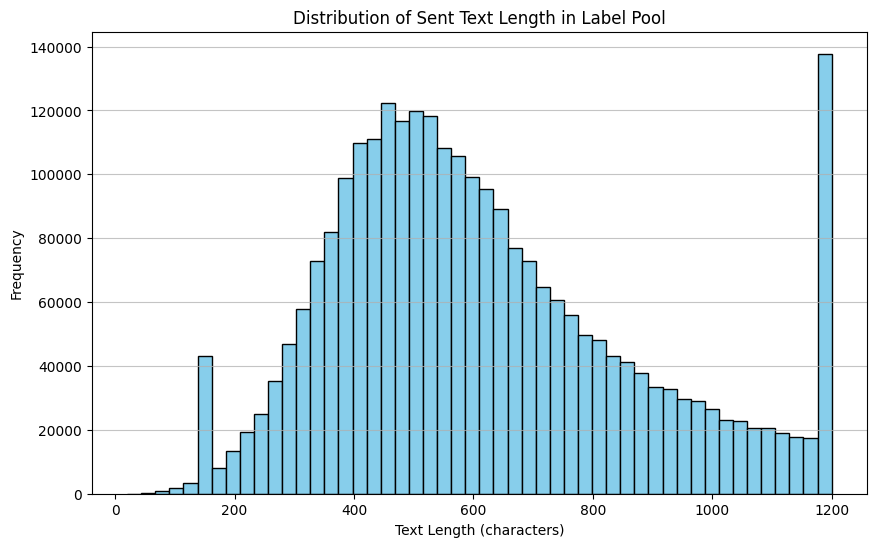

In [11]:
text_length = org_context_df["org_entity_context"].str.len().tolist()

plt.figure(figsize=(10, 6))
plt.hist(text_length, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Sent Text Length in Label Pool")
plt.xlabel("Text Length (characters)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

### Section Takeaway

At this point, the notebook has converted document-level entity outputs into organization-centered context snippets that are much more suitable for sentiment labeling than full article text. This creates the foundation for both weak supervision and downstream classifier training.

## 2. Create Weak Labels with an LLM

### 2.1 Set Up the LLM Labeling Pipeline

This section prepares the weak-labeling workflow used to create training targets at scale. It defines caching logic, retry handling, prompt formatting, and parallel request execution so that a large number of organization-context examples can be labeled efficiently and consistently.

In [ ]:
client = OpenAI(timeout=30.0, max_retries=2)

ALLOWED = {"positive", "neutral", "negative", "unclear"}

CACHE_DIR = Path("./outputs/sentiment")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH = CACHE_DIR / "llm_doc_sentiment_cache.jsonl"


def make_key(row_id: int, text: str) -> str:
    raw = (str(row_id) + "||" + str(text)).encode("utf-8", errors="ignore")
    return hashlib.md5(raw).hexdigest()


cache = {}
if CACHE_PATH.exists():
    with open(CACHE_PATH, "r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            cache[obj["key"]] = obj["label_obj"]


def parse_retry_wait_seconds(msg: str, default_wait: float = 2.0) -> float:
    """
    Try to parse 'Please try again in 130ms' or '... in 2.5s'
    """
    if not msg:
        return default_wait

    m_ms = re.search(r"try again in\s+(\d+(?:\.\d+)?)ms", msg, flags=re.I)
    if m_ms:
        return max(float(m_ms.group(1)) / 1000.0, 0.2)

    m_s = re.search(r"try again in\s+(\d+(?:\.\d+)?)s", msg, flags=re.I)
    if m_s:
        return max(float(m_s.group(1)), 0.2)

    return default_wait


def normalize_label(raw: str) -> str:
    raw = (raw or "").strip().lower()
    if not raw:
        return "unclear"

    token = raw.split()[0].strip(" .,:;!\"'`()[]{}<>")
    if token in ALLOWED:
        return token

    for w in raw.replace("\n", " ").split():
        w = w.strip(" .,:;!\"'`()[]{}<>").lower()
        if w in ALLOWED:
            return w

    return "unclear"


def label_doc_with_llm(text: str, model: str = "gpt-5-nano", max_attempts: int = 8) -> str:
    prompt = (
        "You are a helpful and precise assistant for analyzing the sentiment of sentence(s) extracted from AI-related News articles.\n"
        "Your job is to create a sentiment label (tone) to this sentence. Especially the attitude towards the impact of AI on the industry and organization.\n"
        "The organization in the sentence is marked with <ENT> and </ENT> tags. Focus on the sentiment towards the entity.\n"
        "Rules:\n"
        "- Judge overall tone of the coverage.\n"
        "- If the article is mostly factual or mixed without a clear tilt, choose neutral.\n"
        "- If sentiment cannot be inferred, choose unclear.\n"
        "- Output exactly ONE word from: positive, neutral, negative, unclear.\n"
        "- No punctuation. No explanation.\n\n"
        f"Text:\n{text}"
    )

    for attempt in range(1, max_attempts + 1):
        try:
            resp = client.responses.create(
                model=model,
                input=prompt
            )
            return normalize_label(resp.output_text)

        except openai.RateLimitError as e:
            msg = ""
            try:
                msg = str(e)
            except Exception:
                pass

            wait_s = parse_retry_wait_seconds(msg, default_wait=min(2 ** min(attempt, 6), 20))
            wait_s += random.uniform(0, 0.3)
            time.sleep(wait_s)

        except Exception:

            if attempt == max_attempts:
                return "unclear"
            time.sleep(min(2 ** min(attempt, 5), 10) + random.uniform(0, 0.3))

    return "unclear"


def run_llm_labeling_parallel(
    pool_df: pd.DataFrame,
    model: str = "gpt-5-nano",
    max_workers: int = 10,
    flush_every: int = 100
) -> pd.DataFrame:
    cache_lock = Lock()
    file_lock = Lock()
    new_cache_buffer = []

    def flush_cache_buffer():
        nonlocal new_cache_buffer
        if not new_cache_buffer:
            return
        with file_lock:
            with open(CACHE_PATH, "a", encoding="utf-8") as f:
                for obj in new_cache_buffer:
                    f.write(json.dumps(obj, ensure_ascii=False) + "\n")
        new_cache_buffer = []

    def worker(idx_row):
        idx, r = idx_row
        text = str(r.org_entity_context)
        row_id = int(r.row_id)
        k = make_key(row_id, text)

        with cache_lock:
            if k in cache:
                lab = cache[k]
                return idx, {
                    "row_id": row_id,
                    "industry": r.industry,
                    "org_entity_text": text,
                    "labels": lab
                }

        lab = label_doc_with_llm(text, model=model)
        print(lab)
        with cache_lock:
            if k in cache:
                lab = cache[k]
            else:
                cache[k] = lab
                new_cache_buffer.append({"key": k, "label_obj": lab})
                if len(new_cache_buffer) >= flush_every:
                    flush_cache_buffer()

        return idx, {
            "row_id": row_id,
            "industry": r.industry,
            "org_entity_text": text,
            "labels": lab
        }

    rows = list(pool_df.itertuples(index=False))
    results = [None] * len(rows)

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(worker, (i, row)) for i, row in enumerate(rows)]

        for fut in tqdm(as_completed(futures), total=len(futures)):
            idx, result = fut.result()
            results[idx] = result

    with cache_lock:
        flush_cache_buffer()

    return pd.DataFrame(results)

### 2.2 Sample the Context Dataset and Generate Sentiment Labels

Here I draw a large random sample of organization-centered contexts and send them through the LLM labeling pipeline. The model assigns one of four labels—positive, neutral, negative, or unclear—which are later used as the supervision signal for fine-tuning the classifier.


In [ ]:
sample_df = org_context_df.sample(n=50000, random_state=42).reset_index(drop=True)

labeled_df = run_llm_labeling_parallel(
    sample_df,
    model="gpt-5-nano",
    max_workers=10
)

labeled_df["labels"].value_counts(dropna=False)

  0%|          | 0/50000 [00:00<?, ?it/s]

positive
neutral
positive
positive
positive
positive
positive
neutral
positive
neutral
neutral
neutral
neutral
negative
neutral
positive
neutral
positive
positive
neutral
neutral
neutral
positive
neutral
positive
neutral
neutral
neutral
neutral
positive
neutral
positive
positive
neutral
positive
negative
unclear
positive
positive
neutral
neutral
neutral
positive
positive
neutral
positive
positive
neutral
neutral
neutral
positive
neutral
neutral
positive
positive
positive
positive
neutral
positive
positive
neutral
neutral
negative
neutral
neutral
neutral
neutral
neutral
positive
positive
positive
positive
neutral
neutral
neutral
neutral
positive
neutral
positive
neutral
positive
positive
positive
neutral
neutral
positive
positive
negative
positive
neutral
positive
negative
neutral
positive
neutral
positive
neutral
neutral
neutral
positive
neutral
positive
neutral
neutral
neutral
neutral
positive
neutral
neutral
neutral
positive
negative
positive
neutral
neutral
positive
positive
negativ

labels
neutral     22905
positive    21894
negative     4239
unclear       962
Name: count, dtype: int64

### 2.3 Perform a Quick Manual Check and Save the Labeled Output

This step reviews a small sample of labeled examples to ensure the generated labels look reasonable and then saves the weakly labeled dataset to disk. Persisting this intermediate output makes the downstream training stage reproducible and avoids rerunning the full labeling process.

In [ ]:
for i, row in labeled_df.sample(5, random_state=42).iterrows():
    print(f"Industry: {row['industry']}")
    print(f"Org Entity Text: {row['org_entity_text']}")
    print(f"LLM Label: {row['labels']}")
    print("-" * 50)

Industry: Other/Unclustered
Org Entity Text: Without agreeing to let their work be summarized by AI, the company says it would lose visibility. See also People CEO goes after AI web crawlers, accuses <ENT>Google</ENT> of being a bad actorThe lawsuit also brought up the infamous 2024 federal court ruling that said Google holds a near 90% share of the U.S. search market, saying it gives Google unfair power to control how digital content is accessed and distributed. In February, education platform Chegg also sued Google over the same issue.
LLM Label: negative
--------------------------------------------------
Industry: Other/Unclustered
Org Entity Text: I hope you will act accordingly,” Wang told Rubio, according to a Foreign Ministry statement, employing a Chinese phrase typically used by a teacher or a boss warning a student or employee to behave and be responsible for their actions.The Hockey News - Boston BruinsFormer Bruins Star Traded In Massive BlockbusterThis former <ENT>Bruins</

In [8]:
labeled_df.to_parquet("./data/sentiment/labeled_org_entity_context.parquet", index=False, engine="pyarrow")

### Section Takeaway

This stage produces a weakly labeled sentiment dataset that is large enough to support supervised fine-tuning. Although the labels are generated automatically rather than manually annotated, they provide a practical training signal for building a scalable sentiment classifier.

## 3. Configure and Train the Transformer-Based Sentiment Classifier

### 3.1 Define Training Hyperparameters and Output Paths

This section specifies the base transformer checkpoint, output directory, random seed, and core training hyperparameters. These settings control the reproducibility of the experiment and establish the training configuration used for fine-tuning.

In [7]:
MODEL_NAME = "roberta-base"
OUTPUT_DIR = Path("./outputs/sentiment/roberta-base-news-sentiment")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
set_seed(SEED)

NUM_EPOCHS = 5
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
TRAIN_BATCH_SIZE = 32
EVAL_BATCH_SIZE = 64

### 3.2 Load the Weakly Labeled Data and Encode the Target Labels

This step loads the labeled organization-context dataset and maps the text sentiment labels into integer IDs required by the transformer model. Converting labels into a consistent numeric format ensures that the dataset can be passed directly into the Hugging Face training pipeline.

In [3]:
LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2, "unclear": 3}
ID2LABEL = {v:k for k,v in LABEL2ID.items()}

train_df = pd.read_parquet("./data/sentiment/labeled_org_entity_context.parquet", engine="pyarrow")
train_df["labels"] = train_df["labels"].map(LABEL2ID).astype("int64")

### 3.3 Split the Data and Initialize the Tokenizer

The dataset is divided into training and validation subsets using a stratified split so that label proportions remain similar across both partitions. The text field is then prepared for transformer training by loading the tokenizer associated with the selected base model.


In [4]:
train, val = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["labels"]
)

hf_train = Dataset.from_pandas(train[["org_entity_text","labels"]], preserve_index=False)
hf_val = Dataset.from_pandas(val[["org_entity_text","labels"]], preserve_index=False)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

### 3.4 Tokenize the Text Inputs and Build Hugging Face Datasets

This section converts the organization-centered text snippets into tokenized model inputs with truncation and dynamic padding. The result is a pair of training-ready Hugging Face datasets that can be fed directly into the fine-tuning workflow.

In [5]:
def tokenize(batch):
    return tokenizer(batch["org_entity_text"], truncation=True, max_length=256)

hf_train = hf_train.map(tokenize, batched=True, remove_columns=["org_entity_text"])
hf_val = hf_val.map(tokenize, batched=True, remove_columns=["org_entity_text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

### 3.5 Fine-Tune `roberta-base` with Class-Weighted Loss

This is the core modeling step of the notebook. I initialize a four-class sequence classification version of **`roberta-base`**, compute class weights from the training labels, and use a custom trainer so that less frequent sentiment classes receive more attention during optimization. The evaluation metrics reported during training focus on overall accuracy and macro F1, which is especially useful when class balance is imperfect.


In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

y = train["labels"]
classes = np.array([0,1,2,3])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
weights = weights.astype(np.float32)


class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**{k:v for k,v in inputs.items() if k!="labels"})
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=torch.tensor(weights, device=logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "macro_f1": f1.compute(predictions=preds, references=labels, average="macro")["f1"],
    }


args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=WEIGHT_DECAY,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=50,
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()
trainer.evaluate()

trainer.save_model(str(OUTPUT_DIR))
tokenizer.save_pretrained(str(OUTPUT_DIR))
print("Saved model to:", OUTPUT_DIR)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.813997,0.777417,0.762200,0.604520
2,0.643914,0.852280,0.778700,0.622539
3,0.618286,0.980976,0.795500,0.615906
4,0.473723,1.046154,0.781900,0.618752
5,0.455617,1.277481,0.804000,0.623036


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to: outputs\sentiment\roberta-base-news-sentiment


### Section Takeaway

By the end of this section, the notebook has transformed weakly labeled text snippets into a trained transformer classifier. This moves the workflow from prompt-based labeling toward a reusable supervised model that can score new organization mentions much more efficiently.

## 4. Evaluate Validation Performance

### 4.1 Generate Validation Predictions

After training, the model is applied to the validation split to obtain logits, predicted labels, and confidence scores. These outputs provide the basis for a more detailed assessment of how well the classifier separates the four sentiment categories.


In [9]:
pred_out = trainer.predict(hf_val)
logits = pred_out.predictions
y_true = pred_out.label_ids

probs = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)
y_pred = probs.argmax(axis=1)
conf = probs.max(axis=1)

print("logits:", logits.shape, "y_true:", y_true.shape)

logits: (10000, 4) y_true: (10000,)


### 4.2 Review the Classification Report

This section summarizes performance using per-class precision, recall, and F1-score, along with overall metrics. Looking at class-level results is important because some sentiment categories may be easier to predict than others, especially when the labels were created through weak supervision.

In [10]:
target_names = [ID2LABEL[i] for i in sorted(ID2LABEL.keys())]

print(classification_report(
    y_true, y_pred,
    target_names=target_names,
    digits=4
))

              precision    recall  f1-score   support

    negative     0.6652    0.6958    0.6801       848
     neutral     0.8350    0.7525    0.7916      4581
    positive     0.8446    0.9061    0.8743      4379
     unclear     0.1220    0.1823    0.1461       192

    accuracy                         0.8040     10000
   macro avg     0.6167    0.6342    0.6230     10000
weighted avg     0.8111    0.8040    0.8060     10000



### 4.3 Visualize the Confusion Matrix

The confusion matrix helps diagnose where the model is making mistakes by showing which sentiment classes are most often confused with one another. This is especially useful for understanding whether the classifier struggles with subtle distinctions such as neutral versus unclear or positive versus neutral cases.


,negative,neutral,positive,unclear
negative,590,235,19,4
neutral,260,3447,661,213
positive,23,353,3968,35
unclear,14,93,50,35


<Figure size 600x600 with 0 Axes>

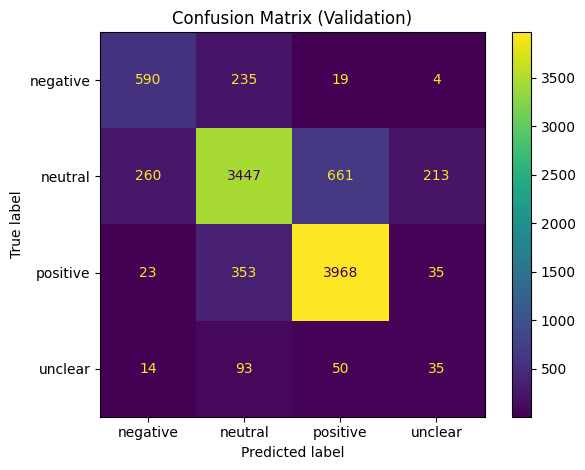

In [12]:
cm = confusion_matrix(y_true, y_pred, labels=[0,1,2,3])
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
display(cm_df)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
plt.figure(figsize=(6,6))
disp.plot(values_format="d")
plt.title("Confusion Matrix (Validation)")
plt.tight_layout()
plt.show()

## Final Takeaway

This notebook builds an end-to-end sentiment modeling pipeline for organization-level AI discussion. Starting from entity extraction outputs, it creates local context snippets, generates weak labels with an LLM, fine-tunes a **`roberta-base`** classifier, and evaluates validation performance using multiple metrics. The trained model provides a scalable way to assign sentiment labels in the downstream analysis of industries, firms, and AI-related impacts.
